# Data Format and Shape Analysis

Before analyzing the metrics, here is a brief overview of how the data is stored and shaped in the evaluation logs (`.jsonl` files):

*   **Format**: JSON Lines (JSONL). Each line is a standalone JSON object representing one sample (one turn of a dialogue).
*   **Shape/Structure**:
    ```json
    {
        "epoch": 0,
        "split": "val",       // or "test"
        "ud_idx": "123",      // Unique Dialogue ID (String)
        "ld_idx": 1,          // Local Dialogue Index (Integer, 0-based turn number)
        "metrics": {          // Nested Dictionary of Metrics
            "ppl": 10.5,
            "acc": 0.85,
            "bleu-1": 0.4,
            ...
        },
        "generated": "...",   // The model's output text
        "target": "..."       // The ground truth text
    }
    ```
*   **Aggregation Logic**: 
    *   **First Turn**: `min(ld_idx)` for a given `ud_idx`.
    *   **Last Turn**: `max(ld_idx)` for a given `ud_idx`.

# Generation Task Metric Analysis
This notebook analyzes the evaluation results from the Generation Task. 
It focuses on comparing the performance of the model on the **First Turn** vs **Last Turn** of each dialogue.

## Requirements
1.  Compute average metrics of **FIRST-TURN** and **LAST-TURN** for each dialogue.
2.  Count how many dialogues have **FIRST-TURN** results better than **LAST-TURN** results.


In [51]:
import os
import glob, re
import json, nltk
import pandas as pd
import numpy as np
from typing import Dict, List, Optional

# 1. Setup Path
# We search for 'eval_results*.jsonl' in the outputs directory
# Adjust this base path if needed
BASE_OUTPUT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs'))

# Target Folders as requested
TARGET_FOLDERS = [
    'Qwen3_02-15',
    'Qwen3_02-21',
    # 'raw_model_Gen_llama3.1_2-24',
    # 'raw_model_Gen_Qwen3_2-24',
    # 'raw_model_Gen_llama3.1_2-25',
    # 'raw_model_Gen_Qwen3_2-25',
    
    'eval_results',
]

jsonl_files = []

print(f"Searching in: {BASE_OUTPUT_DIR}")
for folder in TARGET_FOLDERS:
    # Construct search path: outputs/{folder_name}/**/eval_logs/*.jsonl
    search_path = os.path.join(BASE_OUTPUT_DIR, folder, '**', 'eval_logs', '*.jsonl')
    found_files = glob.glob(search_path, recursive=True)
    
    # Fallback search if 'eval_logs' not found directly inside (e.g. might be simpler structure)
    if not found_files:
         search_path = os.path.join(BASE_OUTPUT_DIR, folder, '**', '*.jsonl')
         found_files = glob.glob(search_path, recursive=True)
         
    jsonl_files.extend(found_files)
    
print(f"[Total] Found {len(jsonl_files)} log files.")
for f in jsonl_files:
    print(f"[Total] - {f}")
    
repattern, repattern2 = r"\w+_last_(test|val)", r"eval_results?_test"
jsonl_files = [jf for jf in jsonl_files if re.search(repattern, jf, flags=re.IGNORECASE) or re.search(repattern2, jf, flags=re.IGNORECASE)]


print(f"[After] Found {len(jsonl_files)} log files.")
for f in jsonl_files:
    print(f" - {f}")

Searching in: /home/new/Documents/QSH/Llama_train/outputs
[Total] Found 10 log files.
[Total] - /home/new/Documents/QSH/Llama_train/outputs/Qwen3_02-15/method_FSL_bs_2_inputdata_input_text_Qwen4B_FSL32/eval_logs/eval_results_epoch_val_4_rank_0.jsonl
[Total] - /home/new/Documents/QSH/Llama_train/outputs/Qwen3_02-15/method_FSL_bs_2_inputdata_input_text_Qwen4B_FSL32/eval_logs/eval_results_epoch_test_4_rank_0.jsonl
[Total] - /home/new/Documents/QSH/Llama_train/outputs/Qwen3_02-15/method_SSP_bs_2_inputdata_input_text_Qwen4B_SSL/eval_logs/eval_results_epoch_test_3_rank_0.jsonl
[Total] - /home/new/Documents/QSH/Llama_train/outputs/Qwen3_02-15/method_SSP_bs_2_inputdata_input_text_Qwen4B_SSL/eval_logs/eval_results_epoch_val_3_rank_0.jsonl
[Total] - /home/new/Documents/QSH/Llama_train/outputs/Qwen3_02-21/method_SSP02_bs_2_inputdata_input_text_Qwen4B_SSL/eval_logs/eval_results_FSL_2shots_last_test.jsonl
[Total] - /home/new/Documents/QSH/Llama_train/outputs/Qwen3_02-21/method_SSP02_bs_2_inputdata_

In [52]:
from collections import Counter
import numpy as np

# --- 1. The Baidu NLP Function ---
def distinct(seqs):
    """ Calculate intra/inter distinct 1/2. """
    batch_size = len(seqs)
    intra_dist1, intra_dist2 = [], []
    unigrams_all, bigrams_all = Counter(), Counter()
    
    for seq in seqs:
        # Intra: Diversity within a single sentence
        unigrams = Counter(seq)
        bigrams = Counter(zip(seq, seq[1:]))
        intra_dist1.append((len(unigrams)+1e-12) / (len(seq)+1e-5))
        intra_dist2.append((len(bigrams)+1e-12) / (max(0, len(seq)-1)+1e-5))

        # Update global counts for Inter metrics
        unigrams_all.update(unigrams)
        bigrams_all.update(bigrams)

    # Inter: Diversity across the whole set of sentences (the whole dialogue)
    inter_dist1 = (len(unigrams_all)+1e-12) / (sum(unigrams_all.values())+1e-5)
    inter_dist2 = (len(bigrams_all)+1e-12) / (sum(bigrams_all.values())+1e-5)
    intra_dist1 = np.average(intra_dist1)
    intra_dist2 = np.average(intra_dist2)
    return intra_dist1, intra_dist2, inter_dist1, inter_dist2

In [86]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Ensure nltk data
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt')
    nltk.download('punkt_tab')

def recompute_metrics(file_path):
    print(f"Processing {file_path}")
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    records = [json.loads(line) for line in lines if line.strip()]
    length = len(records)
    
    chencherry = SmoothingFunction()
    
    # 1. Collect all generated tokens for Corpus-Level Dist metrics
    all_pred_tokens_corpus = []
    dialogues = dict()
    
    # Pre-process records to tokenize
    processed_records = []
    
    for record in records:
        pred_t = record.get('generated', '').strip()
        ref_t = record.get('target', '').strip()
        u_id = record.get('ud_idx')
        
        # Tokenize
        pred_toks = nltk.word_tokenize(pred_t)
            
        if not ref_t:
            ref_toks = []
        else:
            try:
                ref_toks = nltk.word_tokenize(ref_t)
            except Exception:
                ref_toks = ref_t.split()
            
        # Collect for Dist
        all_pred_tokens_corpus.extend(pred_toks)
        if u_id not in dialogues:
            dialogues[u_id] = list()
        dialogues[u_id].append(pred_toks)
        
        processed_records.append({
            'record': record,
            'pred_toks': pred_toks,
            'ref_toks': ref_toks
        })

    # 2. Compute Corpus Level Dist-1/2
    if len(all_pred_tokens_corpus) > 0:
        corpus_dist_1 = len(set(all_pred_tokens_corpus)) / len(all_pred_tokens_corpus)
        bigrams = list(zip(all_pred_tokens_corpus, all_pred_tokens_corpus[1:]))
        corpus_dist_2 = len(set(bigrams)) / len(bigrams) if len(bigrams) > 0 else 0
    else:
        corpus_dist_1, corpus_dist_2 = 0.0, 0.0
    start_ptr, npdist1, npdist2 = 0, np.zeros((length, ), dtype=np.float16), np.zeros((length,), dtype=np.float16)
    for u_id, seqs in dialogues.items():
        intra1, intra2, inter1, inter2 = distinct(seqs)
        intra_len = len(seqs)
        
        npdist1[start_ptr: start_ptr+intra_len] = intra1
        npdist2[start_ptr: start_ptr+intra_len] = intra2
        
        start_ptr += intra_len
        
        
    print(f"Corpus Dist-1: {corpus_dist_1}")
    print(f"Corpus Dist-2: {corpus_dist_2}")
    
    # 3. Recompute BLEU per sample and Update Records
    updated_lines = []
    
    for idx, item in enumerate(processed_records):
        record = item['record']
        pred_toks = item['pred_toks']
        ref_toks = item['ref_toks']
        
        # Calc BLEU (Method 7 as discussed in train_gen.py analysis)
        if len(ref_toks) == 0:
            b1, b2 = 0.0, 0.0
        else:
            # Method 7 interpolates methods 4 (length smoothing) and 5 (average counts)
            # helping with short single-ref sentences
            b1 = sentence_bleu([ref_toks], pred_toks, weights=(1, 0, 0, 0), smoothing_function=chencherry.method7)
            b2 = sentence_bleu([ref_toks], pred_toks, weights=(0.5, 0.5, 0, 0), smoothing_function=chencherry.method7)
            
        # Update Metrics
        if 'metrics' not in record:
            record['metrics'] = {}
            
        record['metrics']['bleu-1'] = b1
        record['metrics']['bleu-2'] = b2
        record['metrics']['dist-1'] = npdist1[idx].item()
        record['metrics']['dist-2'] = npdist2[idx].item()
        record['metrics']['overall_dist-1'] = corpus_dist_1
        record['metrics']['overall_dist-2'] = corpus_dist_2
        
        updated_lines.append(json.dumps(record))
        
    # 4. Write back
    with open(file_path, 'w', encoding='utf-8') as f:
        for line in updated_lines:
            f.write(line + '\n')
            
    print(f"Done recomputing. Updated {len(updated_lines)} records.")

# for tested in jsonl_files:
#     recompute_metrics(tested)

In [53]:
# 2. Load Data into DataFrame
data_records = []

for file_path in jsonl_files:
    # Attempt to extract experiment/run name from path
    # Path format: .../outputs/{Experiment}/{Run}/eval_logs/...
    rel_path = os.path.relpath(file_path, BASE_OUTPUT_DIR)
    parts = rel_path.split(os.sep)
    
    # Heuristic for experiment name
    exp_name = "check_logs" # Default
    if len(parts) >= 2:
        exp_name = f"{parts[0]}/{parts[1]}"
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip(): continue
                record = json.loads(line)
                
                # Flatten metrics for easier pandas use
                metrics = record.pop('metrics', {})
                for k, v in metrics.items():
                    record[f'metric_{k}'] = v
                
                # Add metadata
                record['source_file'] = file_path
                record['experiment'] = exp_name
                
                if 'epoch' not in record:
                    record['epoch'] = -1
                
                # Ensure types
                record['ud_idx'] = str(record.get('ud_idx', 'unknown'))
                record['ld_idx'] = int(record.get('ld_idx', -1))
                
                data_records.append(record)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

df = pd.DataFrame(data_records)
print(f"Loaded {len(df)} records.")
if not df.empty:
    display(df.head())
else:
    print("No data found. Please ensure 'eval_logs' exist and contain valid jsonl files.")


Loaded 5320 records.


,split,ud_idx,ld_idx,generated,target,metric_ppl,metric_loss_iamm,metric_acc,metric_bleu-1,metric_bleu-2,metric_dist-1,metric_dist-2,metric_ppl_iamm,source_file,experiment,epoch,metric_loss
0,last_test,2492,0,"that is great , you are prepared",double check your list . camping is always won...,44.990608,3.806454,0.407407,0.096281,0.058223,0.043936,0.248677,10.813055,/home/new/Documents/QSH/Llama_train/outputs/Qw...,Qwen3_02-21/method_SSP02_bs_2_inputdata_input_...,-1,NaN
1,last_test,2492,1,"yes , i can not even imagine how bad that felt .",did you make a list ?,9.176064,2.216598,0.407407,0.000000,0.000000,0.043936,0.248677,10.813055,/home/new/Documents/QSH/Llama_train/outputs/Qw...,Qwen3_02-21/method_SSP02_bs_2_inputdata_input_...,-1,NaN
2,last_test,2493,0,"oh , you should . i love horror movies .","me either . i do not want too though , lol . a...",16.366926,2.795263,0.315789,0.386201,0.244132,0.043936,0.248677,10.813055,/home/new/Documents/QSH/Llama_train/outputs/Qw...,Qwen3_02-21/method_SSP02_bs_2_inputdata_input_...,-1,NaN
3,last_test,2493,1,you should n't . you will be fine .,oh man . well i used to cuddle a dog when i wo...,40.894825,3.711004,0.315789,0.161514,0.097265,0.043936,0.248677,10.813055,/home/new/Documents/QSH/Llama_train/outputs/Qw...,Qwen3_02-21/method_SSP02_bs_2_inputdata_input_...,-1,NaN
4,last_test,2494,0,that sounds really cool ! what is the name of ...,oh nice . what color is it ?,6.458510,1.865399,0.344828,0.494304,0.294768,0.043936,0.248677,10.813055,/home/new/Documents/QSH/Llama_train/outputs/Qw...,Qwen3_02-21/method_SSP02_bs_2_inputdata_input_...,-1,NaN


### Specificlly designed for all/avg PPL computation

In [49]:
# 2. Load Data into DataFrame
grouped_data = dict()

for file_path in jsonl_files:
    # Attempt to extract experiment/run name from path
    # Path format: .../outputs/{Experiment}/{Run}/eval_logs/...
    rel_path = os.path.relpath(file_path, BASE_OUTPUT_DIR)
    parts = rel_path.split(os.sep)
    inside_staits_records = list()
    
    print('rel_path:', rel_path, 'parts:', parts)
    
    # Heuristic for experiment name
    exp_name = "check_logs" # Default
    if len(parts) >= 2:
        exp_name = f"{parts[0]}/{parts[1]}"
        
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip(): continue
                record = json.loads(line)
                
                # Add metadata
                record['source_file'] = file_path
                record['experiment'] = exp_name
                
                if 'epoch' not in record:
                    record['epoch'] = -1
                
                # Ensure types
                record['ud_idx'] = str(record.get('ud_idx', 'unknown'))
                record['ld_idx'] = int(record.get('ld_idx', -1))
                
                inside_staits_records.append(record)
            grouped_data[parts[0]] = inside_staits_records
    except Exception as e:
        print(f"Error reading {file_path}: {e}")




rel_path: raw_model_Gen_llama3.1_2-24/method_FSL_bs_2_inputdata_input_text_llama31_raw_test_20/eval_logs/eval_results_FSL_16shots_last_test.jsonl parts: ['raw_model_Gen_llama3.1_2-24', 'method_FSL_bs_2_inputdata_input_text_llama31_raw_test_20', 'eval_logs', 'eval_results_FSL_16shots_last_test.jsonl']
rel_path: raw_model_Gen_Qwen3_2-24/method_FSL_bs_2_inputdata_input_text_Qwen3_raw_test_20/eval_logs/eval_results_FSL_16shots_last_test.jsonl parts: ['raw_model_Gen_Qwen3_2-24', 'method_FSL_bs_2_inputdata_input_text_Qwen3_raw_test_20', 'eval_logs', 'eval_results_FSL_16shots_last_test.jsonl']
rel_path: raw_model_Gen_llama3.1_2-25/method_FSL_bs_2_inputdata_input_text_llama31_raw_test_20/eval_logs/eval_results_FSL_16shots_last_test.jsonl parts: ['raw_model_Gen_llama3.1_2-25', 'method_FSL_bs_2_inputdata_input_text_llama31_raw_test_20', 'eval_logs', 'eval_results_FSL_16shots_last_test.jsonl']
rel_path: raw_model_Gen_Qwen3_2-25/method_FSL_bs_2_inputdata_input_text_Qwen3_raw_test_20/eval_logs/eval

In [89]:
# group_data = {
#     'LLaMA3.1': stais_records
# }

In [50]:
for modelres in grouped_data:
    record_metrics = dict()
    
    for singleres in grouped_data[modelres]:
        metrics = singleres.get('metrics', {})
        if not len(metrics): continue
        
        for key, value in metrics.items():
            if value == np.inf or value == -np.inf or np.isnan(value) or (key=='ppl' and value > 3000):
                continue
            if key not in record_metrics:
                record_metrics[key] = (value, 1)
            else:
                current_sum, current_count = record_metrics[key]
                record_metrics[key] = (current_sum + value, current_count + 1)
    
    print(f"Model: {modelres}")
    for key, (total, count) in record_metrics.items():
        avg_value = total / count if count > 0 else 0
        print(f"  {key}: {avg_value:.4f} (based on {count} samples)")

Model: raw_model_Gen_llama3.1_2-24
  loss_iamm: 5.2215 (based on 5121 samples)
  acc: 0.2703 (based on 5121 samples)
  bleu-1: 0.3387 (based on 5121 samples)
  bleu-2: 0.2035 (based on 5121 samples)
  dist-1: 0.0449 (based on 5121 samples)
  dist-2: 0.2214 (based on 5121 samples)
  ppl_iamm: 185.2066 (based on 5121 samples)
  ppl: 305.7024 (based on 4797 samples)
Model: raw_model_Gen_Qwen3_2-24
  loss_iamm: 8.6981 (based on 5121 samples)
  acc: 0.2237 (based on 5121 samples)
  bleu-1: 0.3181 (based on 5121 samples)
  bleu-2: 0.1901 (based on 5121 samples)
  dist-1: 0.0433 (based on 5121 samples)
  dist-2: 0.2074 (based on 5121 samples)
  ppl_iamm: 5991.4119 (based on 5121 samples)
  ppl: 930.0364 (based on 2334 samples)
Model: raw_model_Gen_llama3.1_2-25
  loss_iamm: 5.1295 (based on 10197 samples)
  acc: 0.2728 (based on 10197 samples)
  bleu-1: 0.3398 (based on 10197 samples)
  bleu-2: 0.2042 (based on 10197 samples)
  dist-1: 0.0313 (based on 10197 samples)
  dist-2: 0.1762 (based o

In [54]:
length = len(data_records)

ppl_list = [data_records[i].get('metric_ppl') for i in range(length)]
print(f"{sum(ppl_list)/length:.2f}")

72.58


In [55]:
# 3. Analyze First vs Last Turn
# We need to perform the analysis for each unique experiment and epoch separately.

def analyze_group(group_df):
    """
    Computes analysis for a single group (e.g. one epoch of one experiment).
    Returns nested dictionary with results.
    """
    # 1. Identify First and Last Turns per Unique Dialogue
    # Sort by ud_idx and ld_idx just to be safe
    overall_ppl = group_df['metric_ppl'].mean()
    group_df = group_df.sort_values(['ud_idx', 'ld_idx'])
    
    # Group by Unique Dialogue ID
    dialogue_groups = group_df.groupby('ud_idx')
    
    # Extract First and Last turns
    first_turn_df = dialogue_groups.first().reset_index()
    last_turn_df = dialogue_groups.last().reset_index()
    
    # Limit columns to metrics
    metric_cols = [c for c in group_df.columns if c.startswith('metric_')]
    # assert avg_first.shape[0] == avg_last.shape[0], ''
    
    # 2. Compute Averages
    avg_first = first_turn_df.loc[:, metric_cols].mean().to_dict()
    avg_last = last_turn_df.loc[:, metric_cols].mean().to_dict()
    
    # 3. Compare First vs Last Turn Performance (Count "Better")
    # Join on ud_idx to compare same dialogue
    comparison_df = pd.merge(
        first_turn_df[['ud_idx'] + metric_cols],
        last_turn_df[['ud_idx'] + metric_cols],
        on='ud_idx',
        suffixes=('_first', '_last')
    )
    
    # Filter out dialogues with only 1 turn? (First == Last)
    # The requirement asks "collect in all unique dialogue...". Usually this implies valid transitions.
    # If a dialogue has only 1 turn, it cannot "improve" or "degrade". 
    # But technically First is Better than Last is False if they are equal.
    # We will stick to strict inequality.
    
    comparison_stats = {}
    total_dialogues = len(comparison_df)
    
    for metric in metric_cols[:-4]:
        col_first = f"{metric}_first"
        col_last = f"{metric}_last"
        
        # Determine direction of "Better"
        if 'ppl' in metric.lower() or 'loss' in metric.lower():
            # Lower is Better
            # First Better means First < Last
            is_better = comparison_df[col_first] < comparison_df[col_last]
        else:
            # Higher is Better (BLEU, Acc, Dist)
            # First Better means First > Last
            is_better = comparison_df[col_first] > comparison_df[col_last]
            
        count = is_better.sum()
        
        comparison_stats[metric] = {
            "first_better_count": int(count),
            "total_dialogues": int(total_dialogues),
            "ratio": round(count / total_dialogues, 4) if total_dialogues > 0 else 0
        }
        
    return {
        "metrics_average": {
            'overall_ppl': overall_ppl,
            "first_turn": avg_first,
            "last_turn": avg_last
        },
        "comparison_first_better_than_last": comparison_stats
    }

# Run Analysis
final_results = {}

if not df.empty:
    # Group by key experimental factors
    # experiment: inferred from path
    # epoch, split: from file content
    group_keys = ['experiment', 'epoch', 'split']
    grouped = df.groupby(group_keys)
    
    for name, group in grouped:
        # name is tuple (exp, epoch, split)
        key_str = f"{name[0]} | Epoch {name[1]} | {name[2]}"
        print(f"Analyzing Group: {key_str} (Records: {len(group)})")
        
        res = analyze_group(group)
        final_results[key_str] = res
else:
    print("No data to analyze.")

# Output
print("\n" + "="*40)
print("Analysis Complete. Results:")
print("="*40)
print(json.dumps(final_results, indent=4))


Analyzing Group: Qwen3_02-21/method_SSP02_bs_2_inputdata_input_text_Qwen4B_SSL | Epoch -1 | last_test (Records: 5117)
Analyzing Group: eval_results/eval_results_test.jsonl | Epoch -1 | test (Records: 203)

Analysis Complete. Results:
{
    "Qwen3_02-21/method_SSP02_bs_2_inputdata_input_text_Qwen4B_SSL | Epoch -1 | last_test": {
        "metrics_average": {
            "overall_ppl": 74.61653558956777,
            "first_turn": {
                "metric_ppl": 25.004612247741274,
                "metric_loss_iamm": 2.240100934408362,
                "metric_acc": 0.4714613749742796,
                "metric_bleu-1": 0.37368367248124507,
                "metric_bleu-2": 0.23983598889506333,
                "metric_dist-1": 0.04393611125107098,
                "metric_dist-2": 0.24867705424078249,
                "metric_ppl_iamm": 10.813055216592158,
                "metric_loss": NaN
            },
            "last_turn": {
                "metric_ppl": 127.00448774816142,
              

Plotting for: Qwen3_02-21/method_SSP02_bs_2_inputdata_input_text_Qwen4B_SSL | Epoch -1 | last_test


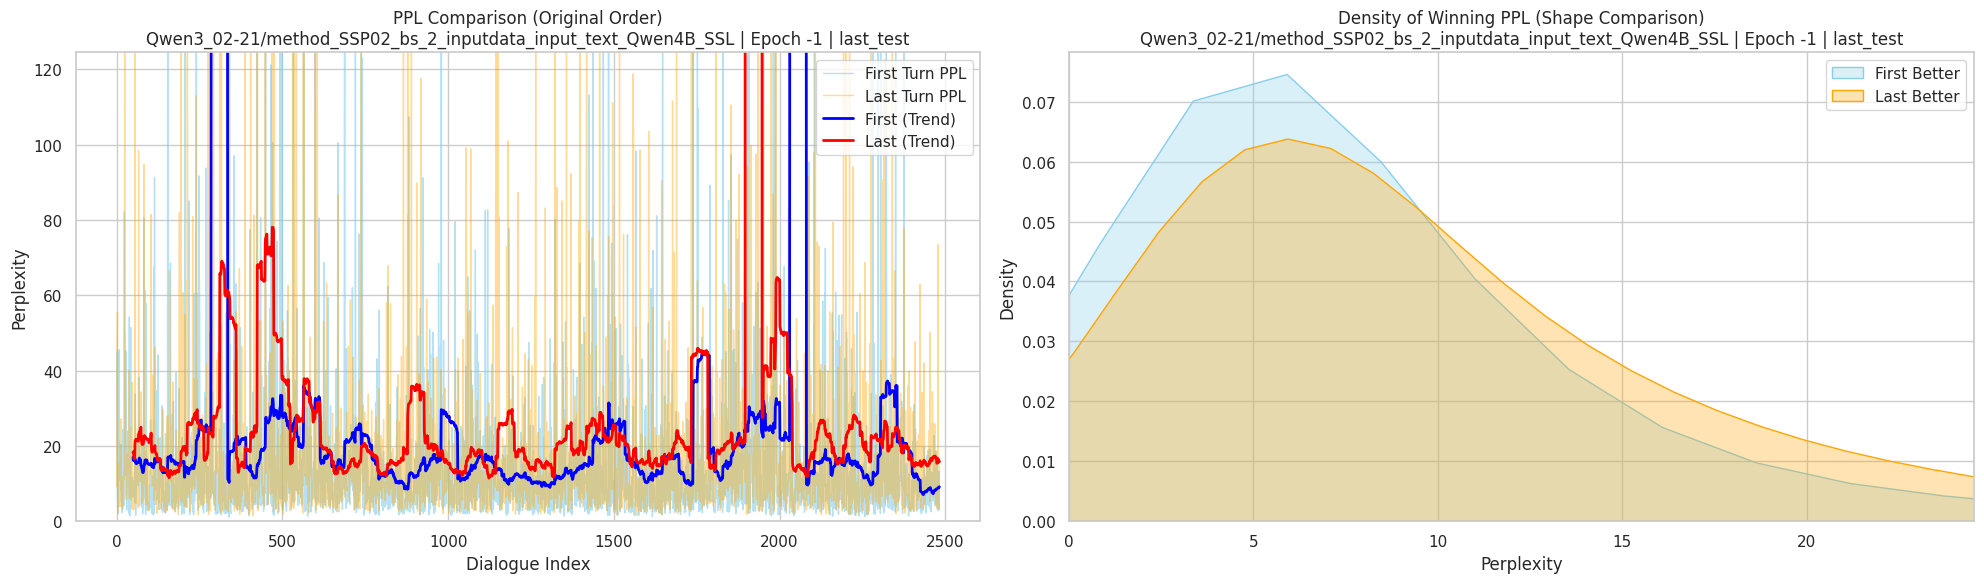

Plotting for: eval_results/eval_results_test.jsonl | Epoch -1 | test


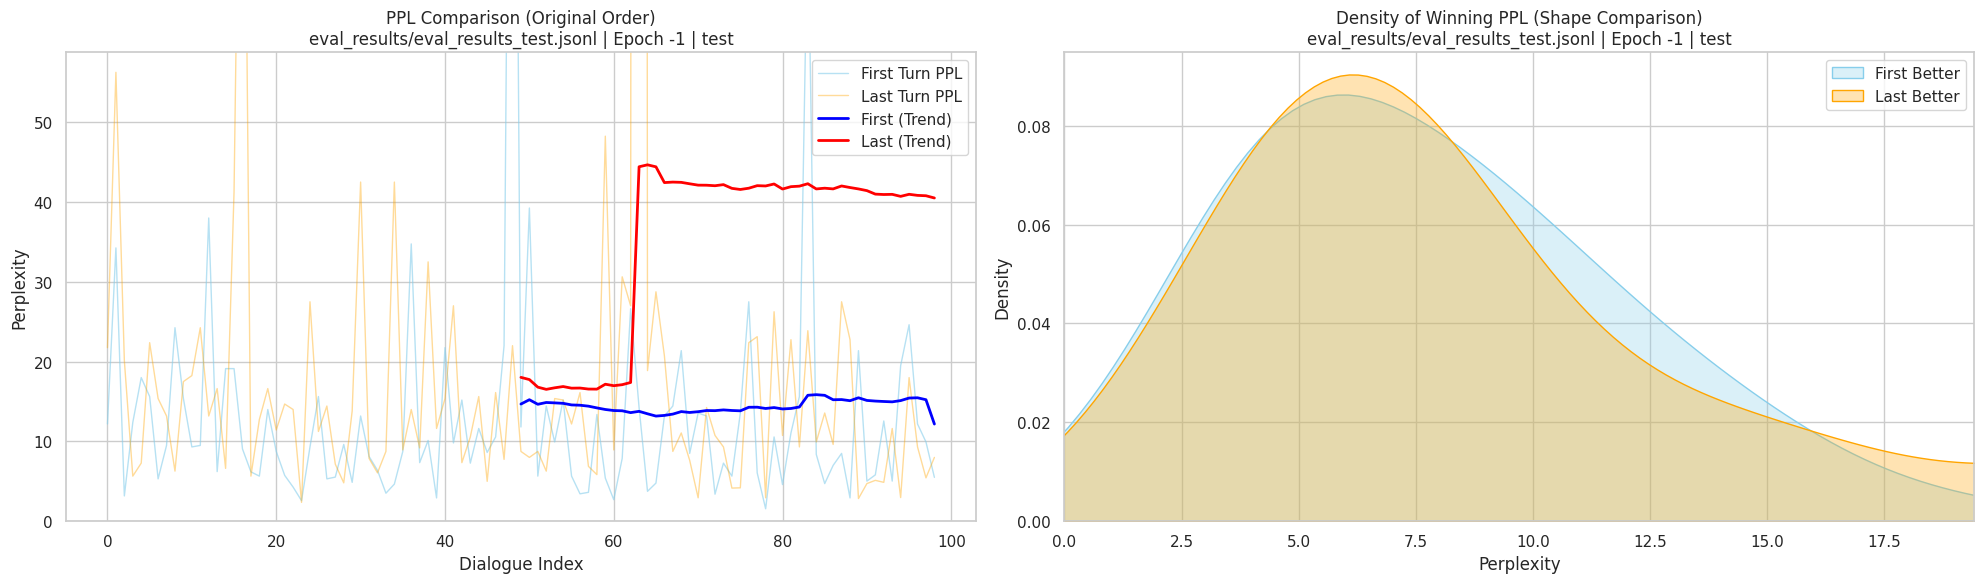

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visuals
sns.set_theme(style="whitegrid")

def plot_ppl_distribution(group_df, title_suffix=""):
    """
    Plots the distribution of PPL for dialogues where First Turn is Better vs Last Turn is Better.
    """
    # 1. Prepare Data
    group_df = group_df.sort_values(['ud_idx', 'ld_idx'])
    dialogue_groups = group_df.groupby('ud_idx')
    
    first_turn_df = dialogue_groups.first().reset_index()
    last_turn_df = dialogue_groups.last().reset_index()
    
    # Merge for comparison
    metric = 'metric_ppl' 
    if metric not in first_turn_df.columns:
        print(f"Metric {metric} not found.")
        return

    # Ensure alignment by merging (so we only compare valid pairs)
    comparison_df = pd.merge(
        first_turn_df[['ud_idx', metric]],
        last_turn_df[['ud_idx', metric]],
        on='ud_idx',
        suffixes=('_first', '_last')
    ).reset_index(drop=True)  # preserve original load order, no sort
    
    # 2. Categorize for Right Plot
    first_better_mask = comparison_df[f'{metric}_first'] < comparison_df[f'{metric}_last']
    data_first_better = comparison_df[first_better_mask][f'{metric}_first']
    data_last_better = comparison_df[~first_better_mask][f'{metric}_last']
    
    # 3. Plot
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    
    # --- LEFT PLOT: Original distribution order (no sorting) ---
    axes[0].plot(comparison_df.index, comparison_df[f'{metric}_first'], color="skyblue", label="First Turn PPL", alpha=0.6, linewidth=1)
    axes[0].plot(comparison_df.index, comparison_df[f'{metric}_last'], color="orange", label="Last Turn PPL", alpha=0.4, linewidth=1)
    
    # Moving average trend lines
    axes[0].plot(comparison_df[f'{metric}_first'].rolling(window=50).mean(), color="blue", label="First (Trend)", linewidth=2)
    axes[0].plot(comparison_df[f'{metric}_last'].rolling(window=50).mean(), color="red", label="Last (Trend)", linewidth=2)

    axes[0].set_title(f"PPL Comparison (Original Order)\n{title_suffix}")
    axes[0].set_xlabel("Dialogue Index")
    axes[0].set_ylabel("Perplexity")
    axes[0].legend()
    
    # Limit Y to ignore extreme spikes
    y_limit = comparison_df[[f'{metric}_first', f'{metric}_last']].quantile(0.98).max()
    axes[0].set_ylim(0, y_limit)


    # --- RIGHT PLOT: Density Estimation of Winning Scores ---
    sns.kdeplot(data_first_better, color="skyblue", label="First Better", fill=True, alpha=0.3, ax=axes[1])
    sns.kdeplot(data_last_better, color="orange", label="Last Better", fill=True, alpha=0.3, ax=axes[1])
    
    axes[1].set_title(f"Density of Winning PPL (Shape Comparison)\n{title_suffix}")
    axes[1].set_xlabel("Perplexity")
    axes[1].set_ylabel("Density")
    
    all_vals = pd.concat([data_first_better, data_last_better])
    if not all_vals.empty:
        axes[1].set_xlim(0, all_vals.quantile(0.95))
        
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Run Plotting Loop
if not df.empty:
    group_keys = ['experiment', 'epoch', 'split']
    grouped = df.groupby(group_keys)
    
    for name, group in grouped:
        key_str = f"{name[0]} | Epoch {name[1]} | {name[2]}"
        print(f"Plotting for: {key_str}")
        plot_ppl_distribution(group, title_suffix=key_str)
else:
    print("No data to plot.")


## Conclusion on Data Storage and Formatting

Based on the analysis code above:
1.  **Storage Format**: The evaluation results are stored in JSON Lines (`.jsonl`) format. Each line represents the evaluation result for a single turn of a dialogue.
2.  **Key Identifiers**:
    *   `ud_idx`: Unique Dialogue ID, used to group turns belonging to the same conversation.
    *   `ld_idx`: Local/Internal Dialogue Index, used to order the turns within a dialogue (min = First Turn, max = Last Turn).
3.  **Metrics**: Standard metrics (Perplexity, BLEU, etc.) are nested under the `metrics` key in each JSON object.
4.  **File Organization**: Files are separated by `epoch`, `split` (val/test), and `rank` (for multi-GPU training), allowing scalable evaluation without race conditions.

The analysis script successfully aggregates these distributed logs to compare the beginning and end of dialogues.
